In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
# read the data
df = pd.read_csv(r"C:\Users\hp\Desktop\data-quality-bank\data\ml\ml_dataset_v2.csv")

In [4]:
df.head(-1)

,table_origine,record_id,rule_id,dimension,severity,label,decision_type,is_valide,date_id,dq_score,contexte_reporting,valeur_metier
0,clients,24,CONTACT_INVALIDE,exactitude,medium,rejected,direct,f,20180115,60,CAMPAGNE_CONTACT,0.00
1,transactions,61411,TX_NON_GAB_AVEC_ID,coherence,medium,accepted,direct,f,20220428,60,CAMPAGNE_CONTACT,10700.08
2,transactions,61404,TX_NON_GAB_AVEC_ID,coherence,medium,accepted,direct,f,20211221,60,CAMPAGNE_CONTACT,6001.62
3,transactions,61201,TX_NON_GAB_AVEC_ID,coherence,medium,accepted,direct,f,20200614,60,CAMPAGNE_CONTACT,2103.28
4,transactions,61131,TX_NON_GAB_AVEC_ID,coherence,medium,accepted,direct,f,20210803,60,CAMPAGNE_CONTACT,19597.66
...,...,...,...,...,...,...,...,...,...,...,...,...
505494,transactions,13883,AUCUNE,aucune,low,accepted,valide,t,20241229,100,ANALYSE_GEOGRAPHIQUE,0.00
505495,transactions,13882,AUCUNE,aucune,low,accepted,valide,t,20210723,100,ANALYSE_GEOGRAPHIQUE,0.00
505496,transactions,13881,AUCUNE,aucune,low,accepted,valide,t,20220601,100,ANALYSE_GEOGRAPHIQUE,0.00
505497,transactions,13880,AUCUNE,aucune,low,accepted,valide,t,20210806,100,ANALYSE_GEOGRAPHIQUE,0.00


In [5]:
df.shape

(505500, 12)

In [6]:
df.columns

Index(['table_origine', 'record_id', 'rule_id', 'dimension', 'severity',
       'label', 'decision_type', 'is_valide', 'date_id', 'dq_score',
       'contexte_reporting', 'valeur_metier'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505500 entries, 0 to 505499
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   table_origine       505500 non-null  object 
 1   record_id           505500 non-null  int64  
 2   rule_id             505500 non-null  object 
 3   dimension           505500 non-null  object 
 4   severity            505500 non-null  object 
 5   label               505500 non-null  object 
 6   decision_type       505500 non-null  object 
 7   is_valide           505500 non-null  object 
 8   date_id             505500 non-null  int64  
 9   dq_score            505500 non-null  int64  
 10  contexte_reporting  505500 non-null  object 
 11  valeur_metier       505500 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 46.3+ MB


In [8]:
df.describe(include='all')

,table_origine,record_id,rule_id,dimension,severity,label,decision_type,is_valide,date_id,dq_score,contexte_reporting,valeur_metier
count,505500,505500.000000,505500,505500,505500,505500,505500,505500,5.055000e+05,505500.000000,505500,505500.000000
unique,5,NaN,9,3,3,2,3,2,NaN,NaN,3,NaN
top,transactions,NaN,AUCUNE,aucune,low,accepted,valide,t,NaN,NaN,CAMPAGNE_CONTACT,NaN
freq,300000,NaN,469820,469820,471311,476860,469820,469820,NaN,NaN,168500,NaN
mean,NaN,37437.443620,NaN,NaN,NaN,NaN,NaN,NaN,1.957748e+07,95.245806,NaN,292.677133
std,NaN,28730.911282,NaN,NaN,NaN,NaN,NaN,NaN,3.546730e+06,17.798993,NaN,3087.287265
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,25.000000,NaN,-2.460000
25%,NaN,11813.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.020123e+07,100.000000,NaN,0.000000
50%,NaN,32875.500000,NaN,NaN,NaN,NaN,NaN,NaN,2.022052e+07,100.000000,NaN,0.000000
75%,NaN,57875.250000,NaN,NaN,NaN,NaN,NaN,NaN,2.023101e+07,100.000000,NaN,0.000000


In [9]:
df.isna().sum()

table_origine         0
record_id             0
rule_id               0
dimension             0
severity              0
label                 0
decision_type         0
is_valide             0
date_id               0
dq_score              0
contexte_reporting    0
valeur_metier         0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [30]:
for col in df.columns[df.dtypes=='object']:
    print(f"{col}: {df[col].unique()} \n")

table_origine: ['clients' 'transactions' 'digital_usage' 'comptes' 'cartes'] 

rule_id: ['CONTACT_INVALIDE' 'TX_NON_GAB_AVEC_ID' 'TX_COMPTE_INEXISTANT'
 'TX_GAB_SANS_ID' 'DIGITAL_CLIENT_INEXISTANT' 'COMPTE_CLIENT_INEXISTANT'
 'CLIENT_AGENCE_FERMEE' 'CARTE_ACTIVE_COMPTE_CLOTURE' 'AUCUNE'] 

dimension: ['exactitude' 'coherence' 'aucune'] 

severity: ['medium' 'high' 'low'] 

label: ['rejected' 'accepted'] 

decision_type: ['direct' 'cascade' 'valide'] 

is_valide: ['f' 't'] 

contexte_reporting: ['CAMPAGNE_CONTACT' 'ANALYSE_GEOGRAPHIQUE' 'ANALYSE_TRANSACTIONNELLE'] 



In [12]:
# Vérifier la cohérence entre is_valide et label

valides = df[df["is_valide"] == "t"]
print("Nombre de valides :", len(valides))

# les valides devraient tous être acceptés
valides_acceptes = valides[valides["label"] == "accepted"]
print("Valides acceptés :", len(valides_acceptes))

# ceux-là ne devraient pas exister
valides_rejetes = valides[valides["label"] == "rejected"]
print("Valides rejetés :", len(valides_rejetes))

if len(valides_rejetes) == 0:
    print("Tout est cohérent")
else:
    print("Probleme : il y a des valides rejetés")

Nombre de valides : 469820
Valides acceptés : 469820
Valides rejetés : 0
Tout est cohérent


In [13]:
df["table_origine"].value_counts()

table_origine
transactions     300000
digital_usage    150000
comptes           21000
cartes            19500
clients           15000
Name: count, dtype: int64

In [14]:
df["decision_type"].value_counts()

decision_type
valide     469820
direct      19617
cascade     16063
Name: count, dtype: int64

In [15]:
df['label'].value_counts(normalize=True) * 100

label
accepted    94.334322
rejected     5.665678
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

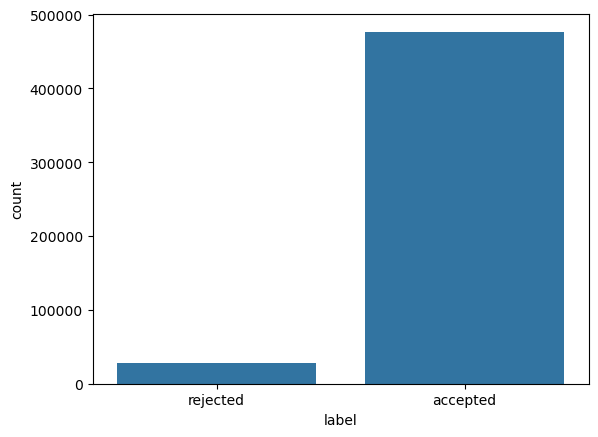

In [16]:
sns.countplot(data=df,x="label")

## Exploration du contexte de reporting

Le contexte de reporting est la nouvelle variable introduite dans ce jeu de données.
Une même anomalie peut être acceptée ou rejetée selon l'objectif du rapport. On
vérifie ici que le contexte a bien un effet sur la décision.

In [17]:
df["contexte_reporting"].value_counts()

contexte_reporting
CAMPAGNE_CONTACT            168500
ANALYSE_GEOGRAPHIQUE        168500
ANALYSE_TRANSACTIONNELLE    168500
Name: count, dtype: int64

In [18]:
# L'effet du contexte sur la décision (en proportion)
pd.crosstab(df["contexte_reporting"], df["label"], normalize="index") * 100

label,accepted,rejected
contexte_reporting,,
ANALYSE_GEOGRAPHIQUE,94.754896,5.245104
ANALYSE_TRANSACTIONNELLE,95.191691,4.808309
CAMPAGNE_CONTACT,93.056380,6.943620


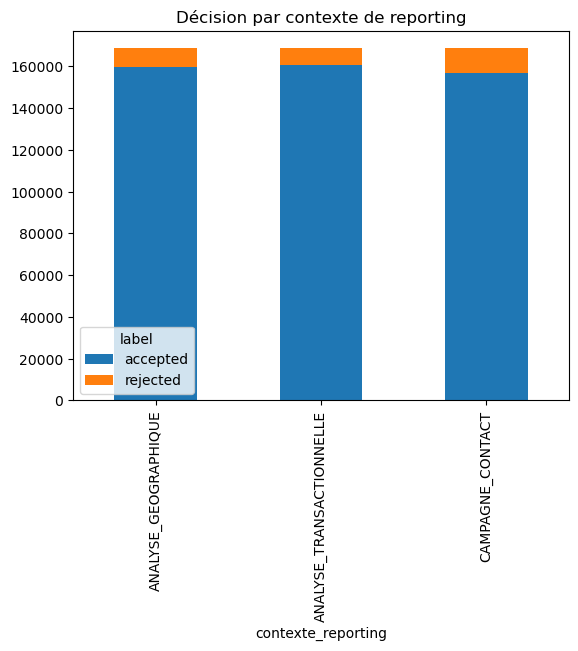

In [19]:
pd.crosstab(df["contexte_reporting"], df["label"]).plot(kind="bar", stacked=True)
plt.title("Décision par contexte de reporting")
plt.show()

In [20]:
# La règle détermine-t-elle la décision ?
pd.crosstab(df["rule_id"], df["label"], normalize="index") * 100

label,accepted,rejected
rule_id,,
AUCUNE,100.000000,0.000000
CARTE_ACTIVE_COMPTE_CLOTURE,28.237129,71.762871
CLIENT_AGENCE_FERMEE,74.496644,25.503356
COMPTE_CLIENT_INEXISTANT,0.000000,100.000000
CONTACT_INVALIDE,66.592428,33.407572
DIGITAL_CLIENT_INEXISTANT,22.604848,77.395152
TX_COMPTE_INEXISTANT,0.000000,100.000000
TX_GAB_SANS_ID,83.568075,16.431925
TX_NON_GAB_AVEC_ID,83.207127,16.792873


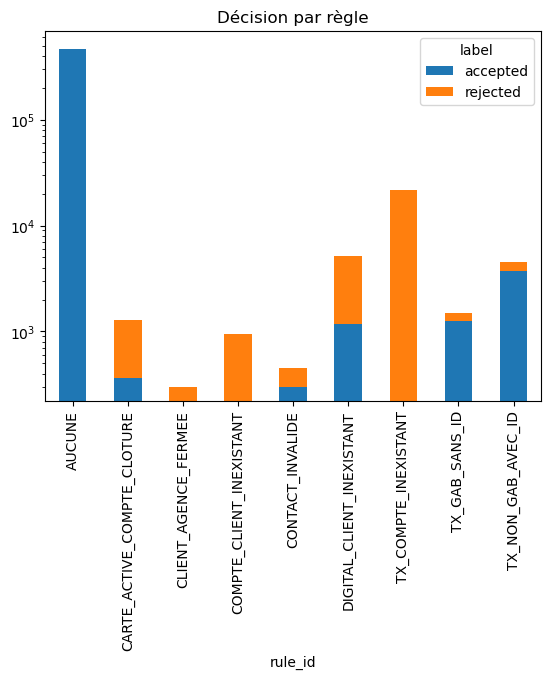

In [21]:
pd.crosstab(df["rule_id"], df["label"]).plot(kind="bar", stacked=True, log=True)
plt.title("Décision par règle")
plt.show()

## Interaction règle × contexte

C'est le cœur du problème d'apprentissage : une même règle peut mener à des
décisions différentes selon le contexte de reporting.

In [22]:
# La même règle change-t-elle de décision selon le contexte ?
pd.crosstab([df["rule_id"], df["contexte_reporting"]], df["label"])

label                                                 accepted  rejected
rule_id                     contexte_reporting                          
AUCUNE                      ANALYSE_GEOGRAPHIQUE        156352         0
                            ANALYSE_TRANSACTIONNELLE    158904         0
                            CAMPAGNE_CONTACT            154564         0
CARTE_ACTIVE_COMPTE_CLOTURE ANALYSE_GEOGRAPHIQUE           137       296
                            ANALYSE_TRANSACTIONNELLE        88       243
                            CAMPAGNE_CONTACT               137       381
CLIENT_AGENCE_FERMEE        ANALYSE_GEOGRAPHIQUE            23        76
                            ANALYSE_TRANSACTIONNELLE       100         0
                            CAMPAGNE_CONTACT                99         0
COMPTE_CLIENT_INEXISTANT    ANALYSE_GEOGRAPHIQUE             0       322
                            ANALYSE_TRANSACTIONNELLE         0       210
                            CAMPAGNE_CONTACT                 0       405
CONTACT_INVALIDE            ANALYSE_GEOGRAPHIQUE           150         0
                            ANALYSE_TRANSACTIONNELLE       149         0
                            CAMPAGNE_CONTACT                 0       150
DIGITAL_CLIENT_INEXISTANT   ANALYSE_GEOGRAPHIQUE          1000       781
                            ANALYSE_TRANSACTIONNELLE       175       825
                            CAMPAGNE_CONTACT                 0      2417
TX_COMPTE_INEXISTANT        ANALYSE_GEOGRAPHIQUE             0      7363
                            ANALYSE_TRANSACTIONNELLE         0      5825
                            CAMPAGNE_CONTACT                 0      8347
TX_GAB_SANS_ID              ANALYSE_GEOGRAPHIQUE           498         0
                            ANALYSE_TRANSACTIONNELLE       250       245
                            CAMPAGNE_CONTACT               498         0
TX_NON_GAB_AVEC_ID          ANALYSE_GEOGRAPHIQUE          1502         0
                            ANALYSE_TRANSACTIONNELLE       732       754
                            CAMPAGNE_CONTACT              1502         0

In [23]:
# La sévérité détermine-t-elle la décision ?
pd.crosstab(df["severity"], df["label"], normalize="index") * 100

label,accepted,rejected
severity,,
high,5.308787,94.691213
low,99.948017,0.051983
medium,81.286996,18.713004


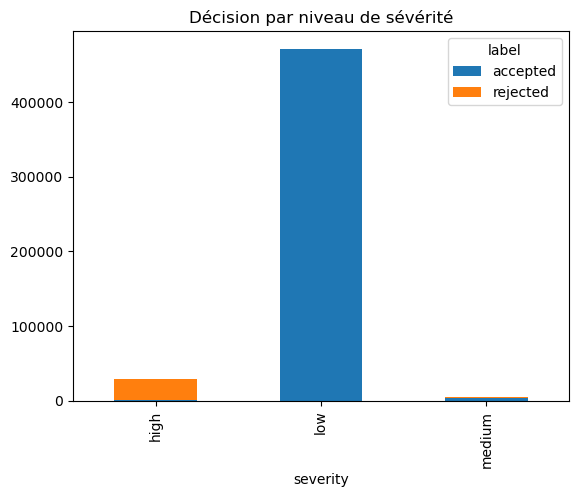

In [24]:
pd.crosstab(df["severity"], df["label"]).plot(kind="bar", stacked=True)
plt.title("Décision par niveau de sévérité")
plt.show()

In [25]:
# La dimension et la décision
pd.crosstab(df["dimension"], df["label"], normalize="index") * 100

label,accepted,rejected
dimension,,
aucune,100.000000,0.000000
coherence,19.133717,80.866283
exactitude,66.592428,33.407572


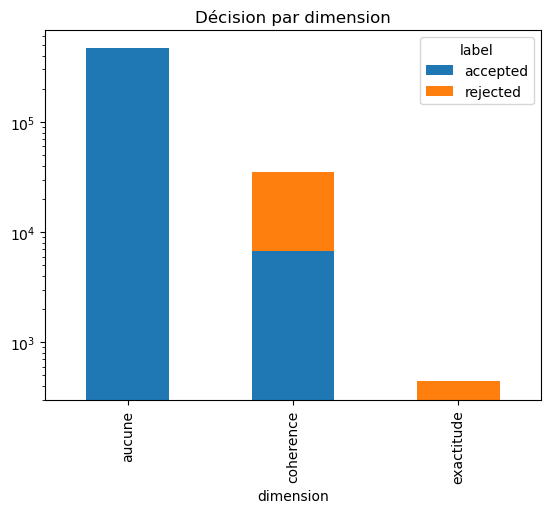

In [26]:
pd.crosstab(df["dimension"], df["label"]).plot(kind="bar", stacked=True, log=True)
plt.title("Décision par dimension")
plt.show()

In [27]:
pd.crosstab(df["table_origine"], df["label"], normalize="index") * 100

label,accepted,rejected
table_origine,,
cartes,95.282051,4.717949
clients,98.493333,1.506667
comptes,95.538095,4.461905
digital_usage,97.318000,2.682000
transactions,92.488667,7.511333


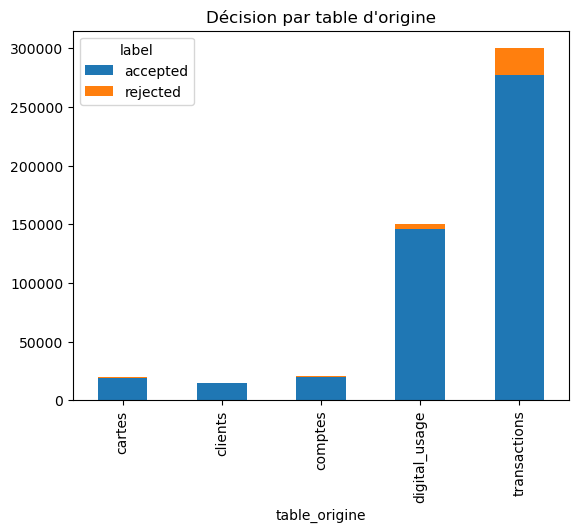

In [28]:
pd.crosstab(df["table_origine"], df["label"]).plot(kind="bar", stacked=True)
plt.title("Décision par table d'origine")
plt.show()

## Exploration de la valeur métier (zones de gris)

La variable `valeur_metier` porte l'attribut métier qui déclenche les zones de gris
(montant, ancienneté, délai avant expiration selon la règle). On vérifie qu'elle
sépare bien les décisions dans une zone de gris.

In [29]:
# Zone de gris : TX_GAB_SANS_ID en contexte transactionnel
gris = df[(df["rule_id"]=="TX_GAB_SANS_ID") &
          (df["contexte_reporting"]=="ANALYSE_TRANSACTIONNELLE")]

print(gris["label"].value_counts())
print()
print("Valeur métier (montant) moyenne par décision :")
print(gris.groupby("label")["valeur_metier"].mean())

label
accepted    250
rejected    245
Name: count, dtype: int64

Valeur métier (montant) moyenne par décision :
label
accepted    15280.436680
rejected    34819.891918
Name: valeur_metier, dtype: float64


In [ ]:
sns.boxplot(data=gris, x="label", y="valeur_metier")
plt.title("TX_GAB_SANS_ID / TRANSAC : montant selon la décision")
plt.show()

## Synthèse de l'analyse exploratoire

L'analyse exploratoire a permis de dégager plusieurs constats qui orienteront
directement les choix de modélisation.

### Constats principaux

**1. Un jeu de données volumineux et fortement déséquilibré.**
Le jeu de données compte environ 505 500 enregistrements, résultant de l'évaluation
de chaque enregistrement dans trois contextes de reporting distincts. La variable
cible `label` présente un déséquilibre marqué : environ 94 % des enregistrements
sont acceptés contre seulement 6 % rejetés. La classe minoritaire (rejeté) est
pourtant celle qui présente le plus d'intérêt à détecter.

**2. Aucune valeur manquante ni doublon.**
Les données sont complètes et ne comportent aucun doublon. La vérification confirme
qu'aucun enregistrement valide n'est rejeté, ce qui atteste de la cohérence du jeu
de données.

**3. Le contexte de reporting influence réellement la décision.**
Contrairement à une version où chaque règle mènerait à une décision fixe, les
tableaux croisés montrent ici que la répartition acceptés/rejetés varie selon le
contexte de reporting. Le contexte de campagne de contact rejette davantage
d'enregistrements, car la règle relative aux moyens de contact y devient critique,
alors qu'elle est tolérée dans les autres contextes. Une même anomalie peut donc
être acceptée dans un contexte et rejetée dans un autre.

**4. Des zones de gris pilotées par la valeur métier.**
Pour certaines règles, la décision ne dépend pas uniquement du contexte mais aussi
d'un attribut métier continu porté par la variable `valeur_metier` (montant,
ancienneté, délai avant expiration selon la règle). L'analyse d'une zone de gris
montre que cette valeur sépare effectivement les décisions : les transactions
rejetées présentent un montant nettement supérieur à celles qui sont acceptées. Le
modèle devra apprendre ces seuils.

**5. La décision résulte d'une interaction, et non d'une correspondance fixe.**
La décision dépend de l'interaction entre la règle violée, le contexte de reporting
et la valeur métier. Le problème d'apprentissage est donc réellement non trivial :
le modèle ne peut se contenter d'une simple correspondance règle vers décision.

### Cadre de prédiction retenu

Le modèle intervient **après la détection de la règle violée** et pour un **contexte
de reporting donné**. Au moment de la prédiction, la règle enfreinte, le contexte du
rapport et la valeur métier de l'enregistrement sont connus. La tâche du modèle
consiste alors à prédire la décision (acceptation ou rejet).

### Choix de modélisation qui en découlent

**Sur les variables explicatives.**
Le choix des variables repose sur deux principes : écarter toute variable
constituant une fuite de données, et éviter la redondance entre variables porteuses
de la même information.

Sont **retenues** :
- `rule_id` : la règle violée, variable centrale la plus granulaire ;
- `contexte_reporting` : l'objectif du rapport, qui conditionne la décision ;
- `valeur_metier` : l'attribut métier continu qui pilote les zones de gris ;
- `table_origine` : l'entité d'origine de l'enregistrement.

Sont **écartées** :
- `dimension` et `severity` : entièrement déduites de `rule_id`, donc redondantes ;
- `is_valide`, `decision_type`, `dq_score` : fuites de données, car dérivées de la
  décision elle-même ;
- `record_id` : simple identifiant, dépourvu de valeur prédictive ;
- `date_id` : sans pertinence pour la décision.

Les variables catégorielles retenues feront l'objet d'un encodage adapté, tandis que
`valeur_metier` sera conservée comme variable numérique.

**Sur le découpage des données.**
En raison du fort déséquilibre, le découpage entre données d'entraînement et de test
sera **stratifié**, afin de préserver la proportion des deux classes dans chaque
sous-ensemble.

**Sur les métriques d'évaluation.**
Toujours en raison du déséquilibre, l'exactitude (accuracy) sera écartée comme
mesure principale au profit de métriques adaptées aux classes déséquilibrées : la
précision, le rappel et le score F1, complétées par la matrice de confusion et
l'aire sous la courbe ROC.

**Sur le traitement du déséquilibre.**
Des stratégies de gestion du déséquilibre seront mises en œuvre lors de
l'entraînement, telles que la pondération des classes ou le rééchantillonnage, afin
d'améliorer la détection de la classe minoritaire.

**Sur le choix des modèles.**
Plusieurs modèles de classification seront comparés, de la régression logistique
(modèle simple servant de référence) aux méthodes d'ensemble plus performantes que
sont la forêt aléatoire et XGBoost, afin de retenir celui offrant le meilleur
compromis sur les métriques retenues.